In [1]:
import pandas as pd

df = pd.read_csv("two_vs_many.csv")

print(df.shape)
display(df.head())

(284009, 4)


,sequence,target,set,validation
0,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-6.824780,train,NaN
1,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-6.500402,train,NaN
2,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,0.900998,NaN,NaN
3,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-4.843517,NaN,NaN
4,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,-6.566587,NaN,NaN


In [2]:
# Training set
# set=train 且没有被标记为 validation
train_df = df[
    (df["set"] == "train") &
    (df["validation"].isna())
].copy()

# Validation set
# set=train 且 validation=True
val_df = df[
    (df["set"] == "train") &
    (df["validation"] == True)
].copy()

# Test set
test_df = df[
    df["set"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total used:", len(train_df) + len(val_df) + len(test_df))

Train: 28626
Validation: 3181
Test: 50776
Total used: 82583


In [3]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Saved successfully.")

Saved successfully.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, vstack
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr, pearsonr

In [5]:
PREFIX_LEN = 560
SUFFIX_LEN = 147

def extract_mutated_region(sequence):
    return sequence[
        PREFIX_LEN : len(sequence) - SUFFIX_LEN
    ]

train_df["mutated_region"] = train_df["sequence"].apply(
    extract_mutated_region
)

val_df["mutated_region"] = val_df["sequence"].apply(
    extract_mutated_region
)

test_df["mutated_region"] = test_df["sequence"].apply(
    extract_mutated_region
)
display(
    train_df[
        ["mutated_region", "target"]
    ].head(10)
)

,mutated_region,target
0,DEEEIRTTNPVATEQYGSVSTNLQRGNR,-6.824780
1,EEEIRTTNPVATEQYGSVSTNLQRGNR,-6.500402
244,ADEEIRTTNPVATEQYGSVSTNLQRGNR,0.575730
766,AEAEIRTTNPVATEQYGSVSTNLQRGNR,-1.249723
1189,AEDEIRTTNPVATEQYGSVSTNLQRGNR,0.270069
1518,AEEEERTTNPVATEQYGSVSTNLQRGNR,-5.662130
1852,AEEEIATTNPVATEQYGSVSTNLQRGNR,3.668798
2035,AEEEIGTTNPVATEQYGSVSTNLQRGNR,0.368345
2070,AEEEIMTTNPVATEQYGSVSTNLQRGNR,0.653414
2075,AEEEIPTTNPVATEQYGSVSTNLQRGNR,-6.270881


In [6]:
WT_REGION = "DEEEIRTTNPVATEQYGSVSTNLQRGNR"

print("WT region:")
print(WT_REGION)

print("Length:", len(WT_REGION))
wt_rows = train_df[
    train_df["mutated_region"] == WT_REGION
]

print("Number of WT-region rows:", len(wt_rows))

display(
    wt_rows[
        ["mutated_region", "target"]
    ].head()
)

WT region:
DEEEIRTTNPVATEQYGSVSTNLQRGNR
Length: 28
Number of WT-region rows: 28


,mutated_region,target
0,DEEEIRTTNPVATEQYGSVSTNLQRGNR,-6.824780
22819,DEEEIRTTNPVATEQYGSVSTNLQRGNR,-4.375918
28513,DEEEIRTTNPVATEQYGSVSTNLQRGNR,-4.450755
42350,DEEEIRTTNPVATEQYGSVSTNLQRGNR,-7.087815
44239,DEEEIRTTNPVATEQYGSVSTNLQRGNR,-5.199868


In [7]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

aa_to_index = {
    aa: i for i, aa in enumerate(AMINO_ACIDS)
}

print(aa_to_index)

{'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4, 'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9, 'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14, 'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19}


In [8]:
MAX_LEN = max(
    train_df["mutated_region"].str.len().max(),
    val_df["mutated_region"].str.len().max(),
    test_df["mutated_region"].str.len().max()
)

print("Maximum region length:", MAX_LEN)

Maximum region length: 42


In [9]:
def one_hot_encode(regions, max_len=MAX_LEN):
    
    rows = []
    cols = []
    data = []

    for sample_idx, sequence in enumerate(regions):

        for position, aa in enumerate(sequence):

            if aa not in aa_to_index:
                continue

            aa_idx = aa_to_index[aa]

            # 每个位点有20个可能的AA
            feature_idx = position * 20 + aa_idx

            rows.append(sample_idx)
            cols.append(feature_idx)
            data.append(1.0)

    X = csr_matrix(
        (data, (rows, cols)),
        shape=(len(regions), max_len * 20),
        dtype=np.float32
    )

    return X

In [10]:
X_train = one_hot_encode(
    train_df["mutated_region"].tolist()
)

X_val = one_hot_encode(
    val_df["mutated_region"].tolist()
)

X_test = one_hot_encode(
    test_df["mutated_region"].tolist()
)

y_train = train_df["target"].to_numpy()
y_val = val_df["target"].to_numpy()
y_test = test_df["target"].to_numpy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (28626, 840)
X_val: (3181, 840)
X_test: (50776, 840)
y_train: (28626,)
y_val: (3181,)
y_test: (50776,)


In [11]:
model = Ridge(
    alpha=1.0,
    solver="lsqr"
)

model.fit(
    X_train,
    y_train
)

print("Training finished.")

Training finished.


In [12]:
val_pred = model.predict(X_val)

val_spearman = spearmanr(
    y_val,
    val_pred
).statistic

val_pearson = pearsonr(
    y_val,
    val_pred
).statistic

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

print(f"Validation Spearman: {val_spearman:.4f}")
print(f"Validation Pearson:  {val_pearson:.4f}")
print(f"Validation RMSE:     {val_rmse:.4f}")

Validation Spearman: 0.8201
Validation Pearson:  0.8499
Validation RMSE:     1.6190


In [13]:
alphas = [
    0.01,
    0.1,
    1,
    10,
    100
]

results = []

for alpha in alphas:

    model = Ridge(
        alpha=alpha,
        solver="lsqr"
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_val)

    spearman = spearmanr(
        y_val,
        pred
    ).statistic

    pearson = pearsonr(
        y_val,
        pred
    ).statistic

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    results.append({
        "alpha": alpha,
        "Spearman": spearman,
        "Pearson": pearson,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

display(results_df)

,alpha,Spearman,Pearson,RMSE
0,0.01,0.820092,0.849952,1.618801
1,0.10,0.820054,0.849942,1.618842
2,1.00,0.820088,0.849905,1.618970
3,10.00,0.820099,0.849642,1.620566
4,100.00,0.809201,0.835440,1.704818


In [14]:
best_row = results_df.loc[
    results_df["Spearman"].idxmax()
]

best_alpha = best_row["alpha"]

print("Best alpha:", best_alpha)

Best alpha: 10.0


In [15]:
from scipy.sparse import vstack

# 合并 Train + Validation
X_train_final = vstack([
    X_train,
    X_val
])

y_train_final = np.concatenate([
    y_train,
    y_val
])

print("Final training X:", X_train_final.shape)
print("Final training y:", y_train_final.shape)

Final training X: (31807, 840)
Final training y: (31807,)


In [17]:
best_alpha = 10

final_model = Ridge(
    alpha=best_alpha,
    solver="lsqr"
)

final_model.fit(
    X_train_final,
    y_train_final
)

print("Final model training finished.")

Final model training finished.


In [54]:
test_pred = final_model.predict(X_test)

test_spearman = spearmanr(
    y_test,
    test_pred
).statistic

test_pearson = pearsonr(
    y_test,
    test_pred
).statistic

test_mse = mean_squared_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(test_mse)

print("===== Final Test Results =====")
print(f"Spearman: {test_spearman:.4f}")
print(f"Pearson:  {test_pearson:.4f}")
print(f"MSE:      {test_mse:.4f}")
print(f"RMSE:     {test_rmse:.4f}")

===== Final Test Results =====
Spearman: 0.0042
Pearson:  -0.0344
MSE:      59.9389
RMSE:     7.7420


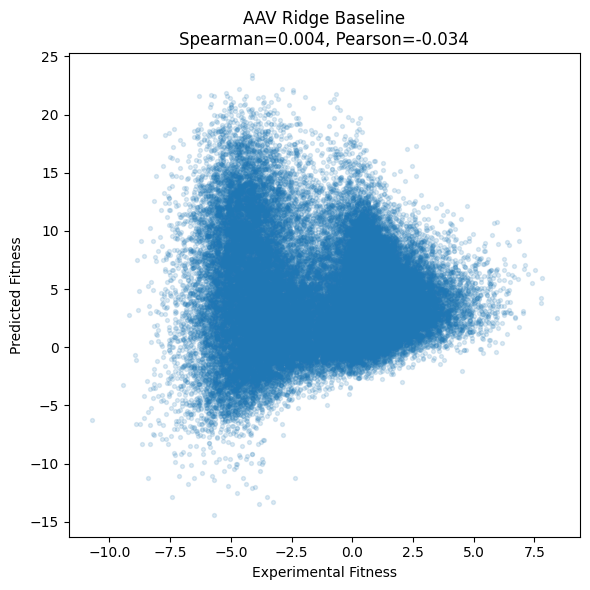

In [19]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.15,
    s=8
)

plt.xlabel("Experimental Fitness")
plt.ylabel("Predicted Fitness")
plt.title(
    f"AAV Ridge Baseline\n"
    f"Spearman={test_spearman:.3f}, "
    f"Pearson={test_pearson:.3f}"
)

plt.tight_layout()
plt.show()

In [20]:
%pip install fair-esm torch tqdm scikit-learn scipy

  Using cached fair_esm-2.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached fair_esm-2.0.0-py3-none-any.whl (93 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 9.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 10.2 MB/s eta 0:00:00a 0:00:01
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import esm

In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

import esm

# device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


/Users/feishenghan/Documents/VScode/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
y_train = train_df["target"].to_numpy(dtype=np.float32)
y_val = val_df["target"].to_numpy(dtype=np.float32)
y_test = test_df["target"].to_numpy(dtype=np.float32)

In [24]:
PREFIX_LEN = 560
SUFFIX_LEN = 147
CONTEXT = 16

WT_REGION = "DEEEIRTTNPVATEQYGSVSTNLQRGNR"
def extract_region_and_context(seq, context=16):
    """
    返回：
    context_seq: mutation region + 左右context
    region_start: mutation region在context_seq中的开始位置
    region_end: mutation region在context_seq中的结束位置
    """

    seq = str(seq)

    # mutation region
    region = seq[PREFIX_LEN : len(seq) - SUFFIX_LEN]

    # 左侧上下文
    left_start = max(0, PREFIX_LEN - context)
    left = seq[left_start:PREFIX_LEN]

    # 右侧上下文
    suffix_start = len(seq) - SUFFIX_LEN
    right = seq[
        suffix_start:
        min(len(seq), suffix_start + context)
    ]

    context_seq = left + region + right

    region_start = len(left)
    region_end = region_start + len(region)

    return context_seq, region_start, region_end

In [25]:
example_seq = train_df.iloc[0]["sequence"]

context_seq, region_start, region_end = extract_region_and_context(
    example_seq
)

print("Context sequence:")
print(context_seq)

print("\nMutation region:")
print(context_seq[region_start:region_end])

print("\nRegion length:")
print(region_end - region_start)

Context sequence:
QGSEKTNVDIEKVMITDEEEIRTTNPVATEQYGSVSTNLQRGNRQAATADVNTQGVLPGM

Mutation region:
DEEEIRTTNPVATEQYGSVSTNLQRGNR

Region length:
28


In [26]:
def get_region_length(seq):
    _, start, end = extract_region_and_context(seq)
    return end - start

print("Train:")
print(
    train_df["sequence"]
    .apply(get_region_length)
    .describe()
)

print("\nTest:")
print(
    test_df["sequence"]
    .apply(get_region_length)
    .describe()
)

Train:
count    28626.000000
mean        28.872319
std          0.720464
min         27.000000
25%         28.000000
50%         29.000000
75%         29.000000
max         30.000000
Name: sequence, dtype: float64

Test:
count    50776.000000
mean        29.525130
std          2.517656
min         28.000000
25%         28.000000
50%         28.000000
75%         30.000000
max         42.000000
Name: sequence, dtype: float64


In [27]:
esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()

esm_model = esm_model.to(device)
esm_model.eval()

for p in esm_model.parameters():
    p.requires_grad = False

batch_converter = alphabet.get_batch_converter()

print("Embedding dim:", esm_model.embed_dim)
print("Layers:", esm_model.num_layers)

Embedding dim: 480
Layers: 12


In [28]:
@torch.inference_mode()
def esm_region_embedding(df, batch_size=32):

    all_embeddings = []

    rows = df["sequence"].tolist()

    for start_idx in tqdm(
        range(0, len(rows), batch_size)
    ):

        batch_sequences = rows[
            start_idx:start_idx + batch_size
        ]

        batch_info = []

        for i, seq in enumerate(batch_sequences):

            context_seq, region_start, region_end = \
                extract_region_and_context(seq)

            batch_info.append(
                (
                    f"seq_{start_idx+i}",
                    context_seq,
                    region_start,
                    region_end
                )
            )

        # ESM input
        esm_data = [
            (name, seq)
            for name, seq, _, _ in batch_info
        ]

        labels, strs, tokens = batch_converter(esm_data)

        tokens = tokens.to(device)

        result = esm_model(
            tokens,
            repr_layers=[12],
            return_contacts=False
        )

        reps = result["representations"][12]

        for i, (
            name,
            seq,
            region_start,
            region_end
        ) in enumerate(batch_info):

            # ESM position 0 是 BOS
            # 所以 residue position +1
            region_rep = reps[
                i,
                region_start + 1 : region_end + 1,
                :
            ]

            pooled = region_rep.mean(dim=0)

            all_embeddings.append(
                pooled.cpu().numpy()
            )

    return np.stack(all_embeddings).astype(
        np.float32
    )

In [30]:
smoke_df = train_df.head(32)

X_test_speed = esm_region_embedding(
    train_df.head(1000),
    batch_size=32
)

print(X_test_speed.shape)

100%|██████████| 32/32 [00:02<00:00, 14.10it/s]

(1000, 480)


In [31]:
X_train_esm = esm_region_embedding(
    train_df,
    batch_size=32
)

print(X_train_esm.shape)

100%|██████████| 895/895 [00:47<00:00, 18.76it/s]

(28626, 480)


In [32]:
np.save(
    "X_train_esm2_35M.npy",
    X_train_esm
)

In [33]:
X_val_esm = esm_region_embedding(
    val_df,
    batch_size=32
)

np.save(
    "X_val_esm2_35M.npy",
    X_val_esm
)

print(X_val_esm.shape)

100%|██████████| 100/100 [00:05<00:00, 18.42it/s]

(3181, 480)


In [34]:
X_val_esm = esm_region_embedding(
    val_df,
    batch_size=32
)

np.save(
    "X_val_esm2_35M.npy",
    X_val_esm
)

print(X_val_esm.shape)

100%|██████████| 100/100 [00:05<00:00, 19.17it/s]

(3181, 480)


In [36]:
X_test_esm = esm_region_embedding(
    test_df,
    batch_size=32
)

np.save(
    "X_test_esm2_35M.npy",
    X_test_esm
)

print(X_test_esm.shape)

100%|██████████| 1587/1587 [01:35<00:00, 16.55it/s]

(50776, 480)


In [37]:
X_train_esm = np.load("X_train_esm2_35M.npy")
X_val_esm = np.load("X_val_esm2_35M.npy")
X_test_esm = np.load("X_test_esm2_35M.npy")

In [38]:
class FitnessMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(480, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [39]:
train_dataset = TensorDataset(
    torch.tensor(
        X_train_esm,
        dtype=torch.float32
    ),
    torch.tensor(
        y_train,
        dtype=torch.float32
    )
)

val_dataset = TensorDataset(
    torch.tensor(
        X_val_esm,
        dtype=torch.float32
    ),
    torch.tensor(
        y_val,
        dtype=torch.float32
    )
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

In [40]:
model = FitnessMLP().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.MSELoss()

best_spearman = -np.inf
best_state = None

patience = 15
counter = 0

history = []

for epoch in range(100):

    # =====================
    # Train
    # =====================

    model.train()

    train_losses = []

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)

        loss = criterion(
            pred,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_losses.append(
            loss.item()
        )

    # =====================
    # Validation
    # =====================

    model.eval()

    val_preds = []
    val_true = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            pred = model(X_batch)

            val_preds.append(
                pred.cpu().numpy()
            )

            val_true.append(
                y_batch.numpy()
            )

    val_preds = np.concatenate(
        val_preds
    )

    val_true = np.concatenate(
        val_true
    )

    val_spearman = spearmanr(
        val_true,
        val_preds
    ).statistic

    val_pearson = pearsonr(
        val_true,
        val_preds
    ).statistic

    val_rmse = np.sqrt(
        mean_squared_error(
            val_true,
            val_preds
        )
    )

    history.append({
        "epoch": epoch + 1,
        "train_mse": np.mean(train_losses),
        "val_spearman": val_spearman,
        "val_pearson": val_pearson,
        "val_rmse": val_rmse
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train MSE {np.mean(train_losses):.3f} | "
        f"Val Spearman {val_spearman:.3f} | "
        f"Val Pearson {val_pearson:.3f} | "
        f"Val RMSE {val_rmse:.3f}"
    )

    # early stopping
    if val_spearman > best_spearman:

        best_spearman = val_spearman

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        counter = 0

    else:

        counter += 1

    if counter >= patience:
        print("Early stopping.")
        break

Epoch 001 | Train MSE 8.633 | Val Spearman 0.524 | Val Pearson 0.592 | Val RMSE 2.491
Epoch 002 | Train MSE 5.338 | Val Spearman 0.616 | Val Pearson 0.678 | Val RMSE 2.270
Epoch 003 | Train MSE 4.640 | Val Spearman 0.661 | Val Pearson 0.710 | Val RMSE 2.190
Epoch 004 | Train MSE 4.359 | Val Spearman 0.686 | Val Pearson 0.728 | Val RMSE 2.106
Epoch 005 | Train MSE 4.094 | Val Spearman 0.707 | Val Pearson 0.747 | Val RMSE 2.078
Epoch 006 | Train MSE 3.936 | Val Spearman 0.724 | Val Pearson 0.760 | Val RMSE 1.998
Epoch 007 | Train MSE 3.791 | Val Spearman 0.738 | Val Pearson 0.771 | Val RMSE 1.960
Epoch 008 | Train MSE 3.601 | Val Spearman 0.749 | Val Pearson 0.783 | Val RMSE 1.944
Epoch 009 | Train MSE 3.633 | Val Spearman 0.750 | Val Pearson 0.783 | Val RMSE 1.922
Epoch 010 | Train MSE 3.437 | Val Spearman 0.759 | Val Pearson 0.795 | Val RMSE 1.875
Epoch 011 | Train MSE 3.467 | Val Spearman 0.764 | Val Pearson 0.800 | Val RMSE 1.883
Epoch 012 | Train MSE 3.255 | Val Spearman 0.767 | Val

In [41]:
model.load_state_dict(best_state)
model = model.to(device)

print(
    "Best Validation Spearman:",
    best_spearman
)

Best Validation Spearman: 0.8357890481659989


In [44]:
X_test_tensor = torch.tensor(
    X_test_esm,
    dtype=torch.float32
)

model.eval()

test_preds = []

with torch.no_grad():

    for i in range(
        0,
        len(X_test_tensor),
        512
    ):

        batch = X_test_tensor[
            i:i+512
        ].to(device)

        pred = model(batch)

        test_preds.append(
            pred.cpu().numpy()
        )

test_pred_esm = np.concatenate(
    test_preds
)
X_test_tensor = torch.tensor(
    X_test_esm,
    dtype=torch.float32
)

model.eval()

test_preds = []

with torch.no_grad():

    for i in range(
        0,
        len(X_test_tensor),
        512
    ):

        batch = X_test_tensor[
            i:i+512
        ].to(device)

        pred = model(batch)

        test_preds.append(
            pred.cpu().numpy()
        )

test_pred_esm = np.concatenate(
    test_preds
)

In [47]:
esm_spearman = spearmanr(
    y_test,
    test_pred_esm
).statistic

esm_pearson = pearsonr(
    y_test,
    test_pred_esm
).statistic

esm_mse = mean_squared_error(
    y_test,
    test_pred_esm
)

esm_rmse = np.sqrt(esm_mse)

print("===== ESM Improved Model =====")
print(f"Spearman: {esm_spearman:.4f}")
print(f"Pearson:  {esm_pearson:.4f}")
print(f"MSE:      {esm_mse:.4f}")
print(f"RMSE:     {esm_rmse:.4f}")

===== ESM Improved Model =====
Spearman: 0.6161
Pearson:  0.6173
MSE:      5.5655
RMSE:     2.3591


In [48]:
comparison = pd.DataFrame({
    "Model": [
        "One-hot + Ridge",
        "ESM-2 + MLP"
    ],

    "Spearman": [
        0.0042,
        esm_spearman
    ],

    "Pearson": [
        -0.0344,
        esm_pearson
    ],

    "RMSE": [
        7.7420,
        esm_rmse
    ]
})

display(comparison)

,Model,Spearman,Pearson,RMSE
0,One-hot + Ridge,0.004200,-0.034400,7.742000
1,ESM-2 + MLP,0.616088,0.617266,2.359125


In [52]:
fractions = [0.01, 0.05, 0.10]

topk_results = []

for fraction in fractions:

    ridge_hit = top_k_hit_rate(
        y_test,
        test_pred,
        fraction
    )

    esm_hit = top_k_hit_rate(
        y_test,
        test_pred_esm,
        fraction
    )

    topk_results.append({
        "Top fraction": f"{fraction*100:.0f}%",
        "Ridge hit rate": ridge_hit,
        "ESM hit rate": esm_hit
    })

topk_df = pd.DataFrame(topk_results)

display(topk_df)

,Top fraction,Ridge hit rate,ESM hit rate
0,1%,0.000000,0.065089
1,5%,0.000394,0.250591
2,10%,0.010242,0.357692


In [56]:
# Ridge结果
ridge_spearman = 0.0042
ridge_pearson = -0.0344
ridge_mse = 59.9386   # 如果你之前没算，可先填近似值
ridge_rmse = 7.7420

# ESM结果
esm_spearman = 0.6161
esm_pearson = 0.6173
esm_mse = 5.5655
esm_rmse = 2.3591

topk_df = pd.DataFrame({
    "Top fraction": ["1%", "5%", "10%"],
    "Ridge hit rate": [0.000000, 0.000394, 0.010242],
    "ESM hit rate": [0.065089, 0.250591, 0.357692]
})

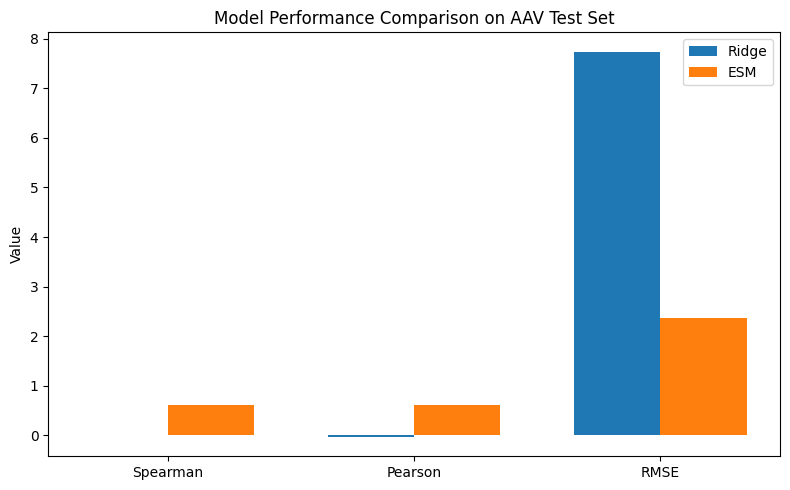

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

metrics_df = pd.DataFrame({
    "Metric": ["Spearman", "Pearson", "RMSE"],
    "Ridge": [ridge_spearman, ridge_pearson, ridge_rmse],
    "ESM": [esm_spearman, esm_pearson, esm_rmse]
})

x = np.arange(len(metrics_df["Metric"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, metrics_df["Ridge"], width, label="Ridge")
plt.bar(x + width/2, metrics_df["ESM"], width, label="ESM")

plt.xticks(x, metrics_df["Metric"])
plt.ylabel("Value")
plt.title("Model Performance Comparison on AAV Test Set")
plt.legend()
plt.tight_layout()
plt.show()

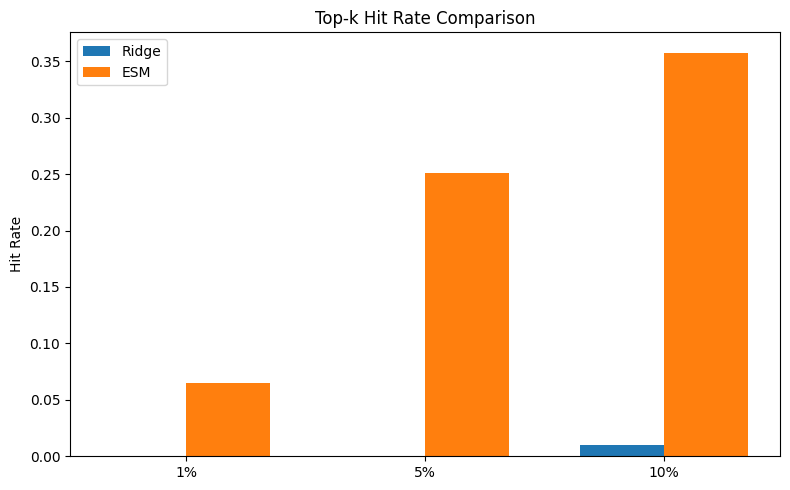

In [59]:
x = np.arange(len(topk_df["Top fraction"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, topk_df["Ridge hit rate"], width, label="Ridge")
plt.bar(x + width/2, topk_df["ESM hit rate"], width, label="ESM")

plt.xticks(x, topk_df["Top fraction"])
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate Comparison")
plt.legend()
plt.tight_layout()
plt.show()

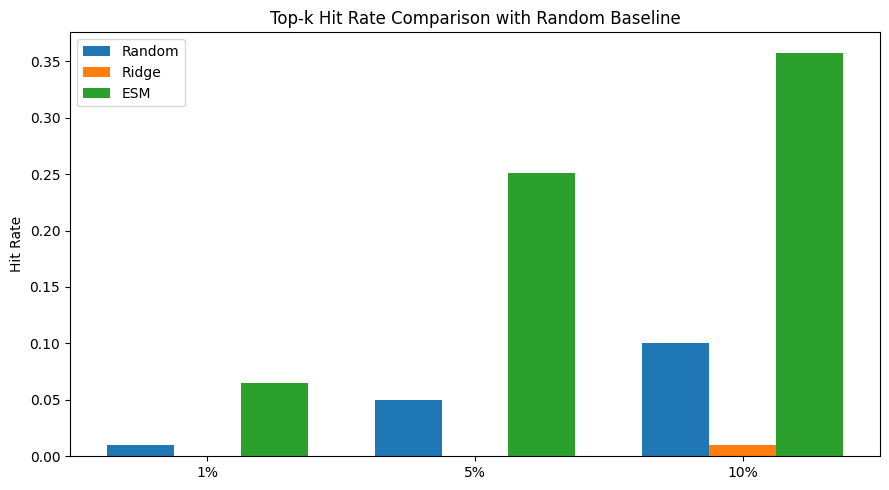

In [60]:
topk_plot_df = topk_df.copy()
topk_plot_df["Random hit rate"] = [0.01, 0.05, 0.10]

x = np.arange(len(topk_plot_df["Top fraction"]))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, topk_plot_df["Random hit rate"], width, label="Random")
plt.bar(x, topk_plot_df["Ridge hit rate"], width, label="Ridge")
plt.bar(x + width, topk_plot_df["ESM hit rate"], width, label="ESM")

plt.xticks(x, topk_plot_df["Top fraction"])
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate Comparison with Random Baseline")
plt.legend()
plt.tight_layout()
plt.show()

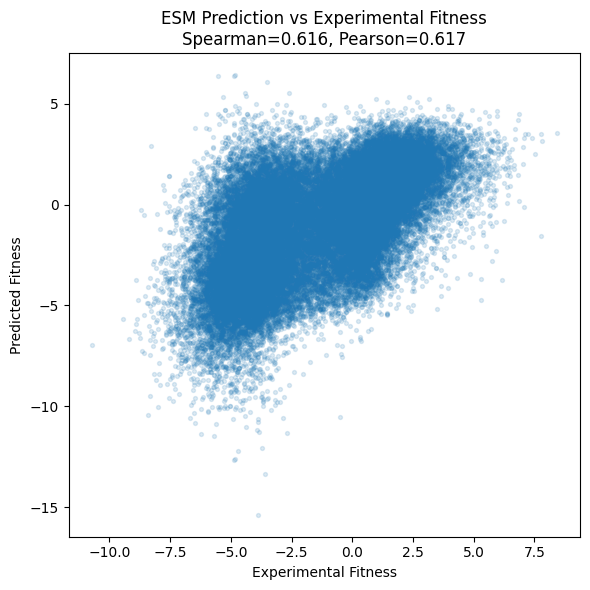

In [61]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred_esm, s=8, alpha=0.15)

plt.xlabel("Experimental Fitness")
plt.ylabel("Predicted Fitness")
plt.title(
    f"ESM Prediction vs Experimental Fitness\n"
    f"Spearman={esm_spearman:.3f}, Pearson={esm_pearson:.3f}"
)

plt.tight_layout()
plt.show()

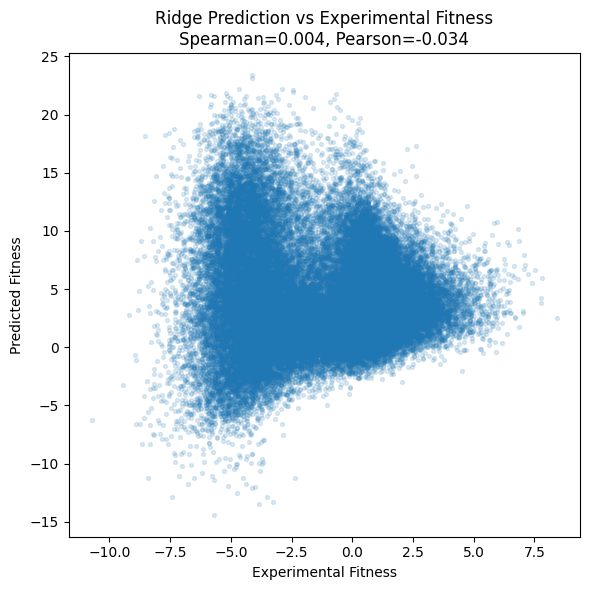

In [62]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, s=8, alpha=0.15)
plt.xlabel("Experimental Fitness")
plt.ylabel("Predicted Fitness")
plt.title(
    f"Ridge Prediction vs Experimental Fitness\n"
    f"Spearman={ridge_spearman:.3f}, Pearson={ridge_pearson:.3f}"
)
plt.tight_layout()
plt.savefig("ridge_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
import os
import torch

os.makedirs("artifacts", exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),

        # ESM配置
        "esm_model_name": "esm2_t12_35M_UR50D",
        "embedding_dim": 480,

        # Fitness MLP结构
        "hidden_dim_1": 256,
        "hidden_dim_2": 64,

        # AAV序列信息
        "prefix_len": 560,
        "suffix_len": 147,
        "context": 16,

        "wt_region": "DEEEIRTTNPVATEQYGSVSTNLQRGNR"
    },
    "artifacts/esm2_fitness_head.pt"
)

print("Model saved.")

Model saved.


In [64]:
observed_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

observed_df[
    ["sequence", "target"]
].to_csv(
    "artifacts/observed_experiments.csv",
    index=False
)

print("Observed experiments:", len(observed_df))

Observed experiments: 31807
